In [9]:
import pandas as pd
from pathlib import Path
file_name = 'Front_EE-1_1_3000x_rings_coords.csv'
path_to_main_folder = Path('/Users/rishabhkumar/spiral-chirals')
# csv_file = Path('/Users/rishabhkumar/spiral-chirals/vf_exports/Front_EE-1_1_3000x_rings_coords.csv')
csv_file = path_to_main_folder / 'vf_exports' / file_name
with open(csv_file, 'r') as f:
    df = pd.read_csv(f)

print(df.head())
# remove the last row 
df = df.iloc[:-1]

  Ring     Coordinate  Angle (α′)        Pattern
0    1   (7.00, 0.00)      -26.09      Clockwise
1    1  (0.00, -7.00)       58.86  Anticlockwise
2    1  (-7.00, 0.00)      -31.99      Clockwise
3    1   (0.00, 7.00)       73.30  Anticlockwise
4    2  (43.00, 0.00)      -11.86      Clockwise


In [10]:
# helper functions 
import ast

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)          # handles "(7.00, 0.00)" or "[7.00, 0.00]"
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]

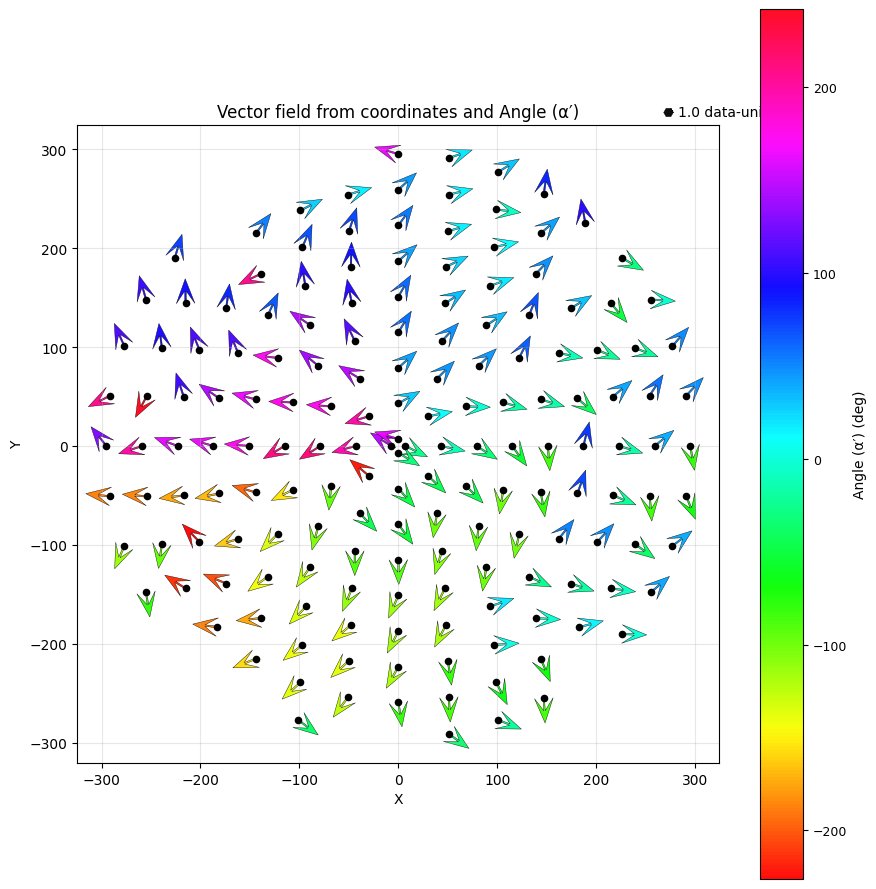

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Extract angles and filter valid data
angles_deg = df['Angle (α′)'].values 

# df['Coordinate'] = df['Coordinate'].apply(lambda x: np.array(x))    
coordinates = df['Coordinate'].apply(parse_coord).tolist()
# Find global theta from the coordinates 



# For these angles and coordinates, plot a vector field
X = [coord[0] for coord in coordinates]
Y = [coord[1] for coord in coordinates]
r = np.sqrt(np.array(X)**2 + np.array(Y)**2) # observed radius
theta = np.arctan2(
    np.array(Y),
    np.array(X)
)
phi = angles_deg + np.degrees(theta) # observed angle in degrees
phi_rad = np.deg2rad(phi) # observed angle in radians
U_plot = np.cos(phi_rad)
V_plot = np.sin(phi_rad)
# Compute a reasonable scale factor for the quiver key
scale_factor = np.round(np.percentile(np.sqrt(U_plot**2 + V_plot**2), 75), 1)
if scale_factor == 0:
    scale_factor = 1.0
# Create the plot
plt.figure(figsize=(9, 9))
magnitude_scale = 25.0
U_plot_scaled = magnitude_scale * U_plot
V_plot_scaled = magnitude_scale * V_plot
q = plt.quiver(
    X, Y, U_plot_scaled, V_plot_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Vector field from coordinates and Angle (α′)')
cbar = plt.colorbar(q, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vector_field_plot.svg', dpi=300)
plt.show()

Commented markdown
<!-- ## Weighted Least Squares Fitting of Angle vs Radius

As shown in the previous vector field fitting experiment, we see that the residuals show ill-fitting vector fields. A possible explanation of this phenomenon is the the heteroskedasticity problem with the statistically equivalent problem. In this notebook, we study the statistically equivalent problem to the least squares minimization and upon fixing the optimization problem, we can get a statistically sound problem for regression. 

### Vector Field Regression
Suppose we measure a noisy vector field in $\{(x_i, y_i) \}_{i = 1}^N \subset \mathbb R^2$ , 
$$
W_i = F(x_i, y_i) + \varepsilon_i
$$

where $\varepsilon_i \sim^{iid} \mathcal N(0, \sigma^2)$ -->

# **Statistical Formulation of the Vector Field Fitting Problem**

## **1. Parametric Spiral Vector Field**

We assume a parametric potential function  
$$
V_\theta(r,\phi) = A\,g_p(r) - b\,\phi,
$$
where  
$$
g_p(r) =
\begin{cases}
\ln r, & p = 0, \\[6pt]
\dfrac{r^p}{p}, & p \neq 0.
\end{cases}
$$
where $r$ is the radial distance, and $\phi$ is the azimuthal angle. 

The induced vector field is the gradient
$$
F_\theta(x,y) = \nabla V_\theta(x,y).
$$

In polar coordinates,
$$
F_\theta(r,\phi)
=
\left(
A g_p'(r),\;
-\frac{b}{r}
\right).
$$

The magnitude of the field is
$$
\rho(r)
=
\big\| F_\theta(r,\phi) \big\|
=
\sqrt{
A^2 \big(g_p'(r)\big)^2
+
\frac{b^2}{r^2}
}.
$$

---

## **2. Noisy Observations**

At spatial points  
$$
Z_i = (x_i, y_i), \quad i = 1,\dots,n,
$$

we observe noisy vector values:
$$
W_i = F_{\theta_0}(Z_i) + \varepsilon_i,
$$
where the noise is isotropic,
$$
\varepsilon_i \sim N(0,\,\sigma^2 I_2).
$$

The observed direction angle is
$$
\hat{\alpha}_i = \operatorname{atan2}(W_{i,2},\; W_{i,1}).
$$

---

## **3. Noise Structure in Angular Coordinates**

Linearizing the Cartesian→polar transformation yields
$$
\hat{\alpha}_i
=
\alpha_{\theta_0}(Z_i)
+
\delta\alpha_i,
$$
with heteroskedastic variance
$$
\operatorname{Var}(\delta\alpha_i)
=
\frac{\sigma^2}{\rho(Z_i)^2}.
$$

Thus angle estimates are noisy in regions where the field magnitude $\rho(r)$ is small.

---

## **4. Statistical Objective (Weighted Least Squares)**

Given observed angles $\hat{\alpha}_i$, estimate $\theta$ by minimizing the discrepancy between  
$\hat{\alpha}_i$ and the predicted angle $\alpha_\theta(Z_i)$.

Under the Gaussian angular noise model, the negative log-likelihood (up to constants) is:
$$
L(\theta)
=
\sum_{i=1}^n 
\rho(Z_i)^2
\big(
\hat{\alpha}_i - \alpha_\theta(Z_i)
\big)^2.
$$

Because angles lie on the circle, we may instead use a wrapped loss:
$$
L(\theta)
=
\sum_{i=1}^n 
\rho(Z_i)^2
\sin^2
\!\big(
\hat{\alpha}_i - \alpha_\theta(Z_i)
\big).
$$

Both losses are statistically valid; they differ only at higher-order terms when the angle errors are small.

---

## **5. Summary**

- Noisy observations follow  
  $$
  W_i = F_{\theta_0}(Z_i) + \varepsilon_i.
  $$

- Angle noise is heteroskedastic:  
  $$
  \operatorname{Var}(\hat{\alpha}_i) = \frac{\sigma^2}{\rho(Z_i)^2}.
  $$

- The statistically correct estimator of $\theta$ is **weighted least squares**:
  $$
  \hat{\theta}
  =
  \arg\min_\theta
  \sum_i
  \rho(Z_i)^2\,
  d\big(
    \hat{\alpha}_i,\,
    \alpha_\theta(Z_i)
  \big),
  $$
  where $d(x,y)$ is either $(x-y)^2$ or $\sin^2(x-y)$.

This fully specifies the statistically rigorous formulation of the **spiral vector field regression problem**.


# **Spiral Vector Fields: Summary Table**

| **Spiral Type** | **$g_p'(r)$** | **Vector Field** $F(r,\phi)$ | **Magnitude** $\rho(r)$ | **Weight** $w(r)=\rho(r)^2$ | **Weighted LS Objective** $L(\theta)$ |
|-----------------|---------------|-------------------------------|--------------------------|------------------------------|----------------------------------------|
| **Log Spiral** | $$\frac{1}{r}$$ | $$F_{\text{log}}(r,\phi)=\left(\frac{A}{r},\;-\frac{b}{r}\right)$$ | $$\rho_{\text{log}}(r)=\frac{\sqrt{A^2+b^2}}{r}$$ | $$w_{\text{log}}(r)=\frac{A^2+b^2}{r^2}$$ | $$L_{\text{log}}(\theta)=\sum_i \frac{A^2+b^2}{r_i^2}\ d^2(\hat{\alpha}_i,\alpha_\theta) = 1/b^2\sum_i \frac{1/k^2 + 1}{r_i^2}\ d^2(\hat{\alpha}_i,\alpha_\theta)  \\ = L_{\log}(k)$$ |
| **Archimedean Spiral** | $$1$$ | $$F_{\text{arch}}(r,\phi)=\left(A,\;-\frac{b}{r}\right)$$ | $$\rho_{\text{arch}}(r)=\sqrt{A^2+\frac{b^2}{r^2}}$$ | $$w_{\text{arch}}(r)=A^2+\frac{b^2}{r^2}$$ | $$L_{\text{arch}}(\theta)=\sum_i \left(A^2+\frac{b^2}{r_i^2}\right)\ d^2(\hat{\alpha}_i,\alpha_\theta)$$ |
| **Fermat Spiral** | $$r$$ | $$F_{\text{fermat}}(r,\phi)=\left(A r,\;-\frac{b}{r}\right)$$ | $$\rho_{\text{fermat}}(r)=\sqrt{A^2 r^2+\frac{b^2}{r^2}}$$ | $$w_{\text{fermat}}(r)=A^2 r^2+\frac{b^2}{r^2}$$ | $$L_{\text{fermat}}(\theta)=\sum_i \left(A^2 r_i^2+\frac{b^2}{r_i^2}\right)\ d^2(\hat{\alpha}_i,\alpha_\theta)$$ |
---

For log spirals $r = a \exp (k \theta)$, we can set $A$ and $b$ in the above model such that $A / b = 1 / k$. Parameter $a$ acts as a relative constant, controlling the level set of the potential curves, hence setting $A/b = 1/k$. 

For Archimedean spiral vector fields, $r = b \theta$, we set $A = 1$, $b=b$, with $p = 1$ for the parameterized function $g_p(\cdot)$.

For Fermat spirals, $r^2 = a^2 \theta$, we set $A = 2$, $b = a^2$, with $p = 2$ for the parameterized function $g_p(\cdot)$. 


Optimized k (least squares): 16.0585 degrees
Optimized k (sin squared): 10.3192 degrees
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 213.9853981308204
        x: [ 1.606e+01]
      nit: 11
      jac: [ 5.722e-06]
 hess_inv: [[ 4.911e+00]]
     nfev: 24
     njev: 12
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.04884440807245794
        x: [ 1.032e+01]
      nit: 11
      jac: [-2.723e-06]
 hess_inv: [[ 3.173e+04]]
     nfev: 28
     njev: 14


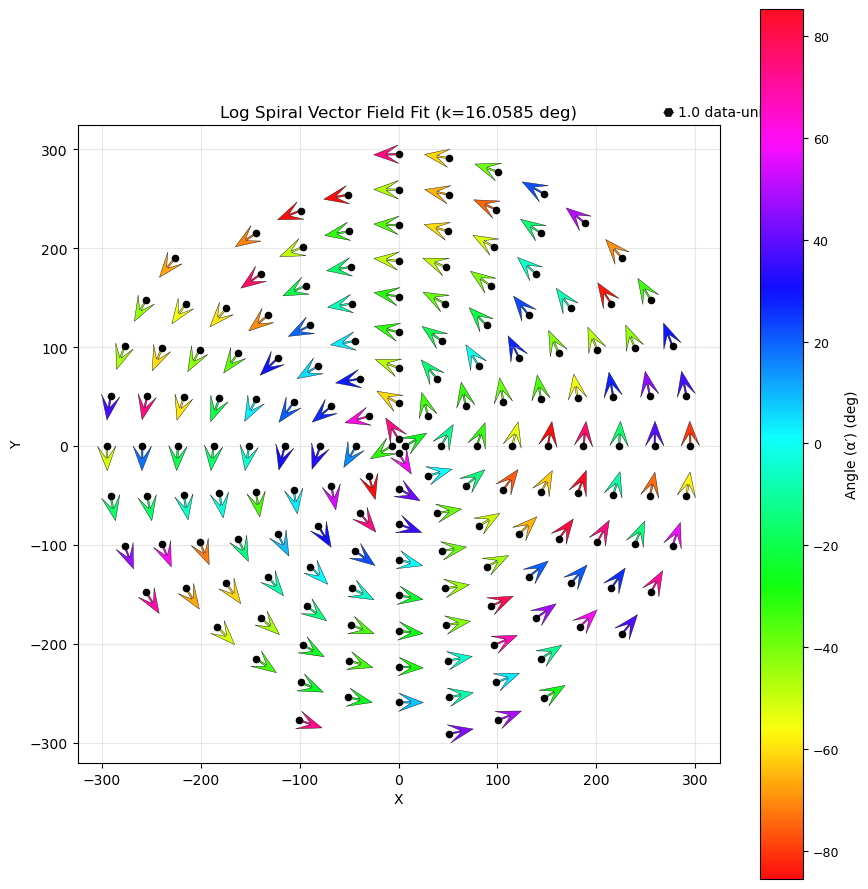

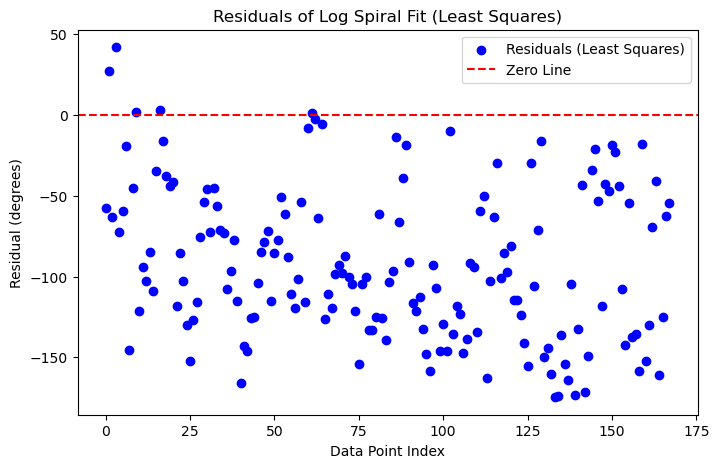

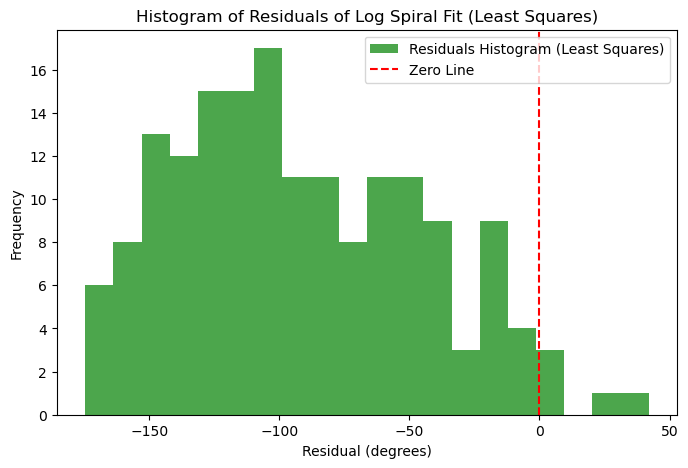

In [11]:
## Solve the least squares problem to fit spirals
from scipy.optimize import minimize
def objective_log_spiral(k, angles, r, scaling = True): # One only observes angles and $r$
    if scaling:
        residuals = np.sqrt(1/k**2 + 1)/r * (angles - k)
    else:
        residuals = angles - k
    return np.sum(residuals**2)

def objective_log_spiral_sin(k, angles, r, scaling = True):
    if scaling == True: 
        residuals = np.sqrt(1/k**2 + 1)/r * np.sin(np.deg2rad(angles - k))
    else:
        residuals = np.sin(np.deg2rad(angles - k))
    return np.sum(residuals**2)

# Initial guess for k
k0 = 2.0
# Optimize using the first objective function
result1 = minimize(objective_log_spiral, k0, args=(angles_deg, r))
k_opt1 = result1.x[0]
# Optimize using the second objective function
result2 = minimize(objective_log_spiral_sin, k0, args=(angles_deg, r))
k_opt2 = result2.x[0]

print(f"Optimized k (least squares): {k_opt1:.4f} degrees")
print(f"Optimized k (sin squared): {k_opt2:.4f} degrees")
print(result1)
print(result2)

# ------- PLOTTING THE FITTED VECTOR FIELD -------
# Plotting log spiral vector field with above parameters (k_opt1 and k_opt2)
def log_spiral_vector_field(x, y, k):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    alpha_prime = k * np.log(r + 1e-8)  # add small value to avoid log(0)
    phi = theta + np.deg2rad(alpha_prime)
    Vx = np.cos(phi)
    Vy = np.sin(phi)
    return Vx, Vy

Vx1, Vy1 = log_spiral_vector_field(np.array(X), np.array(Y), k_opt1)
Vx2, Vy2 = log_spiral_vector_field(np.array(X), np.array(Y), k_opt2)
# Plotting
plt.figure(figsize=(9, 9))
magnitude_scale = 25.0
U1_scaled = magnitude_scale * Vx1
V1_scaled = magnitude_scale * Vy1
U2_scaled = magnitude_scale * Vx2
V2_scaled = magnitude_scale * Vy2

q1 = plt.quiver(
    X, Y, U1_scaled, V1_scaled, angles_deg,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)

plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Log Spiral Vector Field Fit (k={k_opt1:.4f} deg)')
cbar = plt.colorbar(q1, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q1, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('log_spiral_vector_field_fit.svg', dpi=300)
plt.show()

## Plot residuals 
predicted_angles = k_opt1 * np.log(r + 1e-8)
residuals1 = angles_deg - predicted_angles

plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals1)), residuals1, color='blue', label='Residuals (Least Squares)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Log Spiral Fit (Least Squares)')
plt.legend()

plt.figure(figsize=(8, 5))
plt.hist(residuals1, bins=20, color='green', alpha=0.7, label='Residuals Histogram (Least Squares)')
plt.axvline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals of Log Spiral Fit (Least Squares)')
plt.legend()
plt.show()

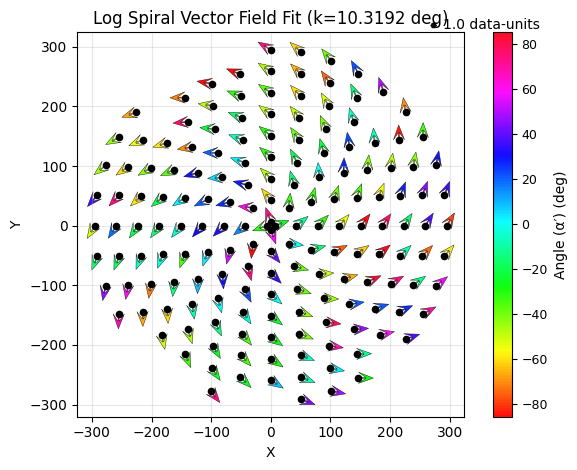

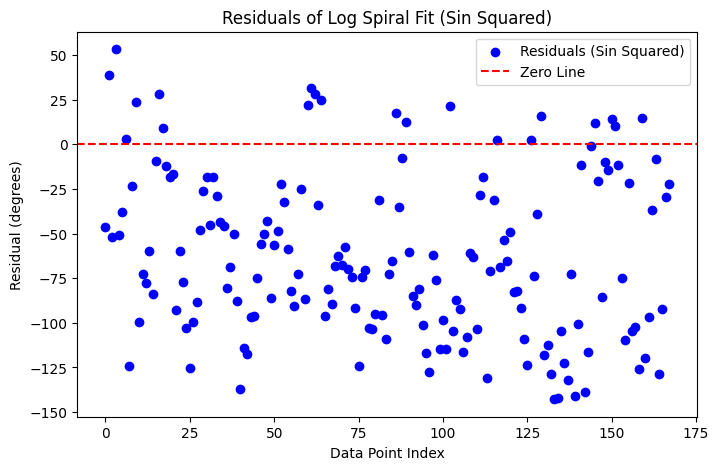

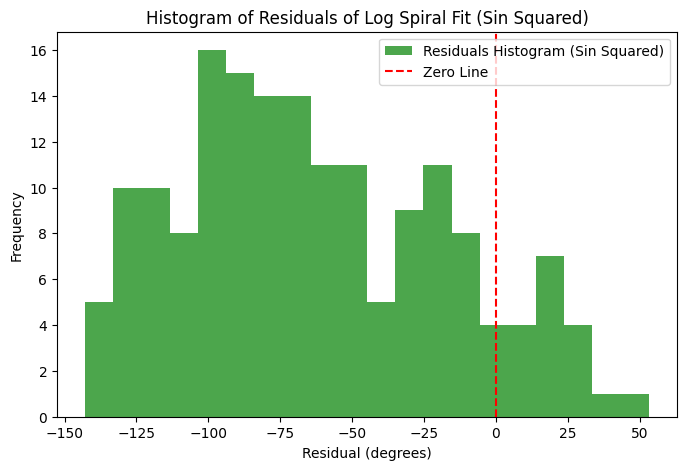

In [5]:
q2 = plt.quiver(
    X, Y, U2_scaled, V2_scaled, angles_deg,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)

plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Log Spiral Vector Field Fit (k={k_opt2:.4f} deg)')
cbar = plt.colorbar(q2, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q2, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('log_spiral_vector_field_fit_sin.svg', dpi=300)
plt.show()

## Plot residuals
residuals2 = angles_deg - (k_opt2 * np.log(r + 1e-8))
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals2)), residuals2, color='blue', label='Residuals (Sin Squared)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Log Spiral Fit (Sin Squared)')
plt.legend()
plt.figure(figsize=(8, 5))
plt.hist(residuals2, bins=20, color='green', alpha=0.7, label='Residuals Histogram (Sin Squared)')
plt.axvline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals of Log Spiral Fit (Sin Squared)')
plt.legend()
plt.show()


Optimized b (least squares): 19.7756
Optimized b (sin squared): -312.0434
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 1892297.9345883976
        x: [ 1.978e+01]
      nit: 8
      jac: [ 1.562e-02]
 hess_inv: [[ 1.308e-04]]
     nfev: 68
     njev: 28
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 58.99974099052007
        x: [-3.120e+02]
      nit: 7
      jac: [ 5.245e-06]
 hess_inv: [[ 4.961e+03]]
     nfev: 24
     njev: 12


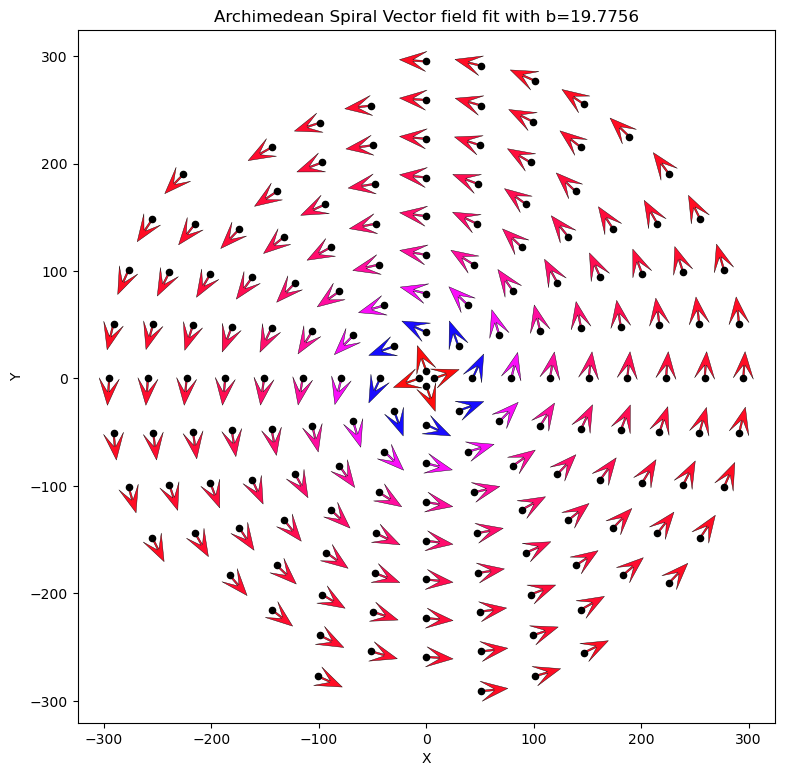

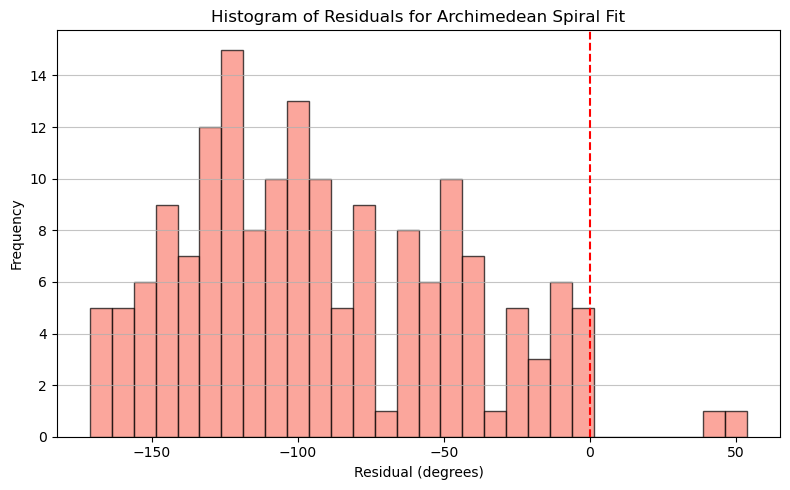

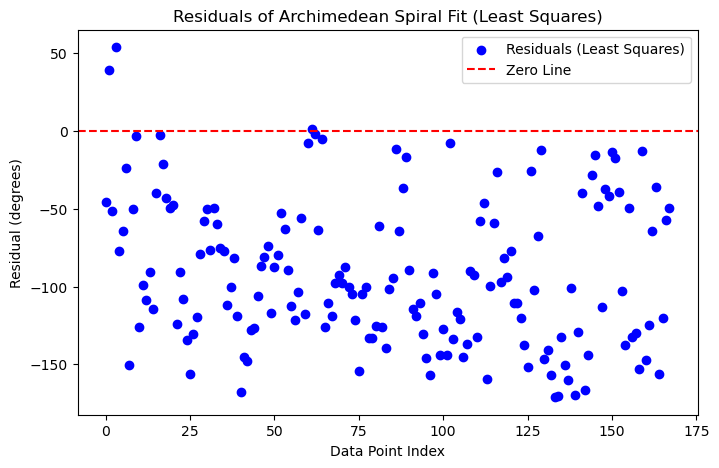

In [6]:
# Case 2: Archimedean Spiral
## Solve the least squares problem to fit spirals
def objective_archimedean_spiral(b, angles, r, scaling = True):
    predicted_angles = np.degrees(np.arctan(r / b))
    if scaling:
        residuals = np.sqrt(r**2 + b**2)/r * (angles - predicted_angles)
    else:
        residuals = angles - predicted_angles
    # residuals = angles - predicted_angles
    return np.sum(residuals**2)

def objective_archimedean_spiral_sin(b, angles, r, scaling = True):
    if scaling == True: 
        residuals = np.sqrt(r**2 + b**2)/r * np.sin(np.deg2rad(angles - np.degrees(np.arctan(r / b))))
    predicted_angles = np.degrees(np.arctan(r / b))
    residuals = np.sin(np.deg2rad(angles - predicted_angles))
    return np.sum(residuals**2)

# Initial guess for b
b0 = 1.0
# Optimize using the objective function
result5 = minimize(objective_archimedean_spiral, b0, args=(angles_deg, r))
b_opt1 = result5.x[0]
# Optimize using the sin squared objective function
result6 = minimize(objective_archimedean_spiral_sin, b0, args=(angles_deg, r))
b_opt2 = result6.x[0]
print(f"Optimized b (least squares): {b_opt1:.4f}")
print(f"Optimized b (sin squared): {b_opt2:.4f}")
print(result5)
print(result6)

## Plot the vector field with the fitted Archimedean spirals and their residuals
predicted_angles_archimedean = np.degrees(np.arctan(r / b_opt1))
residuals_archimedean = angles_deg - predicted_angles_archimedean
# For each x_i, y_i coordinate, compute the predicted vector from the fitted spiral
for i in range(len(coordinates)):
    r_i = r[i]
    theta_i = theta[i]
    fitted_angle = predicted_angles_archimedean[i]
    phi_fitted = fitted_angle + np.degrees(theta_i)
    phi_fitted_rad = np.deg2rad(phi_fitted)
    U_fitted = np.cos(phi_fitted_rad)
    V_fitted = np.sin(phi_fitted_rad)

plt.figure(figsize=(9, 9))
U_fitted_scaled = magnitude_scale * np.cos(np.deg2rad(predicted_angles_archimedean + np.degrees(theta)))
V_fitted_scaled = magnitude_scale * np.sin(np.deg2rad(predicted_angles_archimedean + np.degrees(theta)))
q_fitted = plt.quiver(
    X, Y, U_fitted_scaled, V_fitted_scaled, predicted_angles_archimedean,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)   
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Archimedean Spiral Vector field fit with b={b_opt1:.4f}')
plt.show()

## Plot residuals histogram for Archimedean spiral fit
plt.figure(figsize=(8, 5))
plt.hist(residuals_archimedean, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Line')

plt.title('Histogram of Residuals for Archimedean Spiral Fit')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals_archimedean)), residuals_archimedean, color='blue', label='Residuals (Least Squares)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Archimedean Spiral Fit (Least Squares)')
plt.legend()


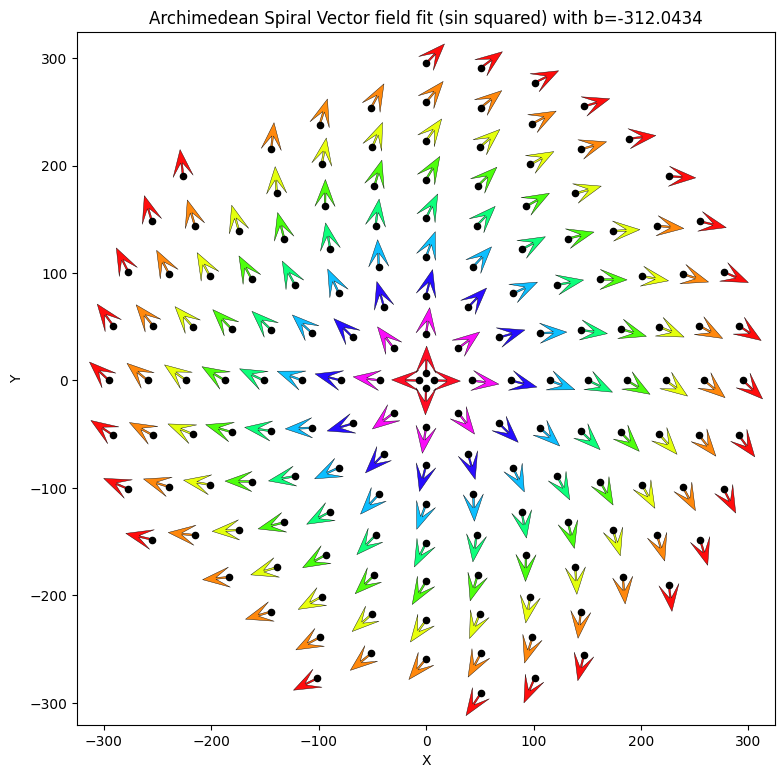

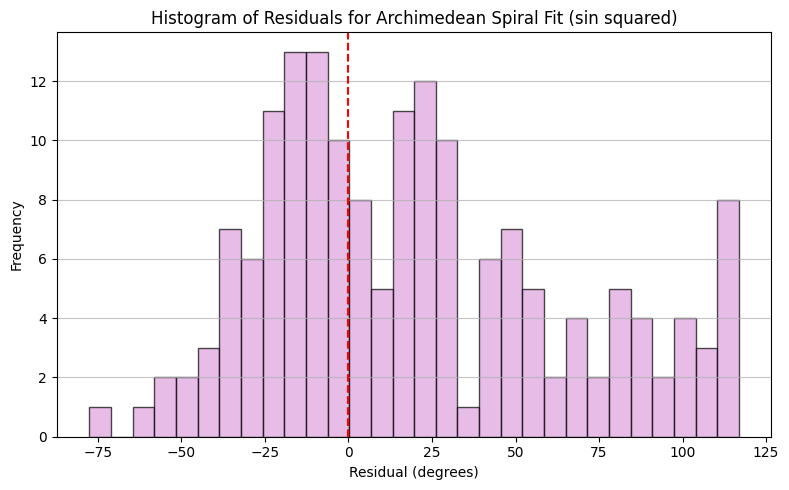

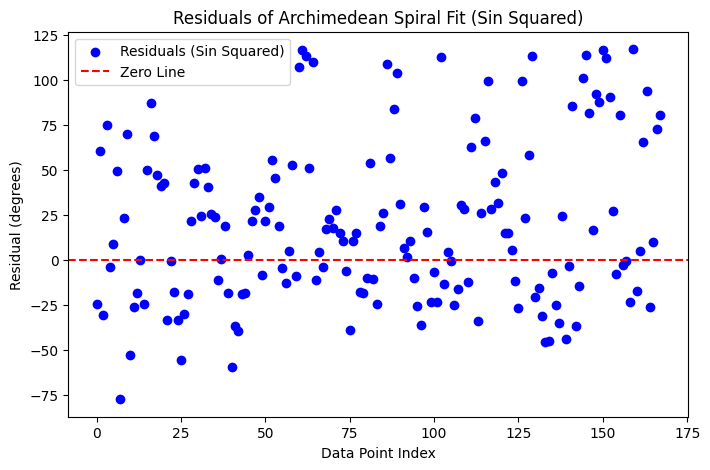

In [7]:
# Plot predicted vector field for Archimedean spiral (sin squared)
predicted_angles_archimedean2 = np.degrees(np.arctan(r / b_opt2))
residuals_archimedean2 = angles_deg - predicted_angles_archimedean2
plt.figure(figsize=(9, 9))
U_fitted_scaled2 = magnitude_scale * np.cos(np.deg2rad(predicted_angles_archimedean2 + np.degrees(theta)))
V_fitted_scaled2 = magnitude_scale * np.sin(np.deg2rad(predicted_angles_archimedean2 + np.degrees(theta)))
q_fitted2 = plt.quiver(
    X, Y, U_fitted_scaled2, V_fitted_scaled2, predicted_angles_archimedean2,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Archimedean Spiral Vector field fit (sin squared) with b={b_opt2:.4f}')
plt.show()  

# plot residuals histogram for Archimedean spiral fit (sin squared)
plt.figure(figsize=(8, 5))
plt.hist(residuals_archimedean2, bins=30, color='plum', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Line')
plt.title('Histogram of Residuals for Archimedean Spiral Fit (sin squared)')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals_archimedean2)), residuals_archimedean2, color='blue', label='Residuals (Sin Squared)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Archimedean Spiral Fit (Sin Squared)')
plt.legend()


In [8]:
# Case 3: Fermat Spiral
## Solve the least squares problem to fit spirals

def objective_fermat_spiral(a, angles, r, scaling = True):
    predicted_angles = np.degrees(np.arctan(2 * r**2 / a**2))
    if scaling:
        residuals = np.sqrt(4 * r**4 + a**4)/r * (angles - predicted_angles)
    else:
        residuals = angles - predicted_angles
    return np.sum(residuals**2)

def objective_fermat_spiral_sin(a, angles, r, scaling = True):
    if scaling == True: 
        residuals = np.sqrt(4 * r**4 + a**4)/r * np.sin(np.deg2rad(angles - np.degrees(np.arctan(2 * r**2 / a**2))))
    else:
        residuals = np.sin(np.deg2rad(angles - np.degrees(np.arctan(2 * r**2 / a**2))))
    return np.sum(residuals**2)

# Initial guess for a
a0 = 1.0
# Optimize using the objective function
result3 = minimize(objective_fermat_spiral, a0, args=(angles_deg, r))
a_opt1 = result3.x[0]
# Optimize using the sin squared objective function
result4 = minimize(objective_fermat_spiral_sin, a0, args=(angles_deg, r))
a_opt2 = result4.x[0]
print(f"Optimized a (least squares): {a_opt1:.4f}")
print(f"Optimized a (sin squared): {a_opt2:.4f}")
print(result3)
print(result4)

Optimized a (least squares): 78.0219
Optimized a (sin squared): -0.0004
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 348727712086.3609
        x: [ 7.802e+01]
      nit: 4
      jac: [ 0.000e+00]
 hess_inv: [[ 7.425e-08]]
     nfev: 22
     njev: 11
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 15305236.138930889
        x: [-3.803e-04]
      nit: 3
      jac: [ 0.000e+00]
 hess_inv: [[ 6.413e-03]]
     nfev: 8
     njev: 4


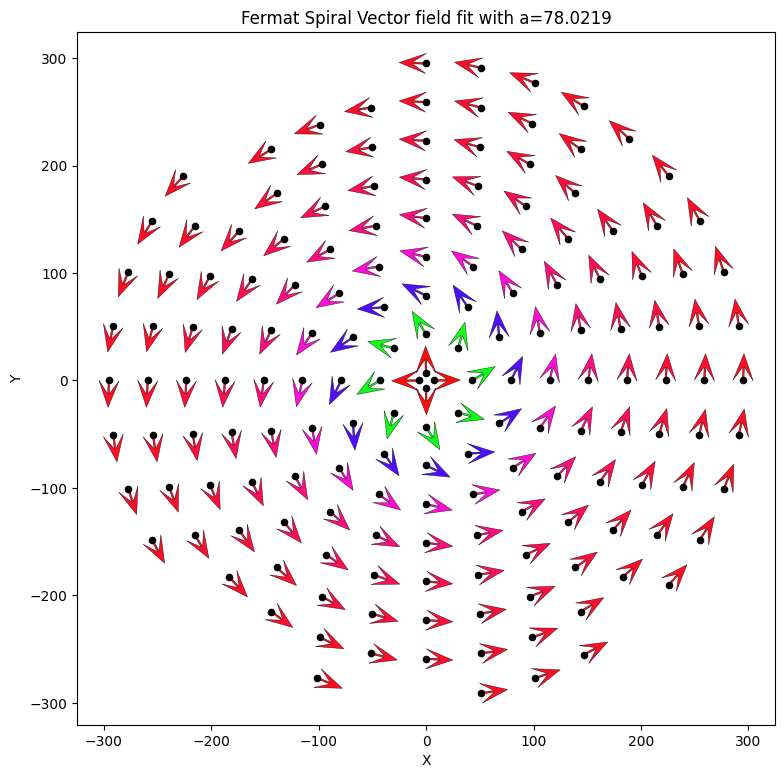

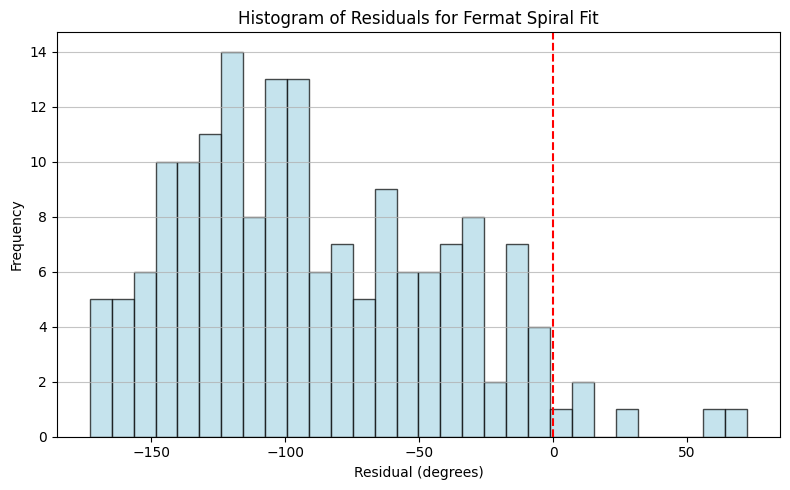

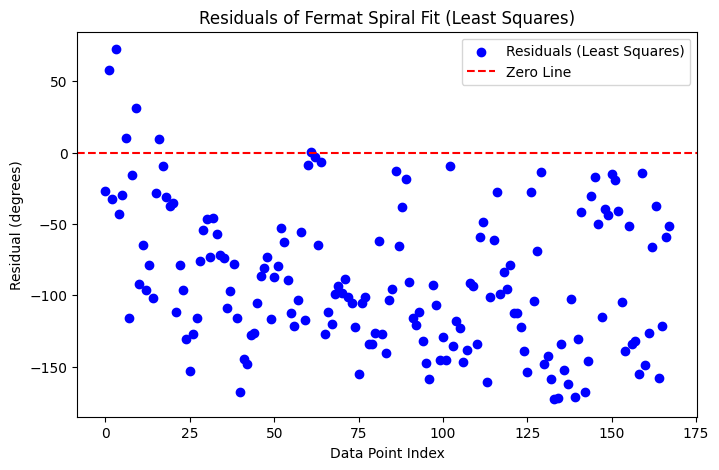

In [9]:
## plot the vector field with the fitted Fermat spirals and their residuals
predicted_angles_fermat = np.degrees(np.arctan(2 * r**2 / a_opt1**2))
residuals_fermat = angles_deg - predicted_angles_fermat
# For each x_i, y_i coordinate, compute the predicted vector from the fitted spiral
for i in range(len(coordinates)):
    r_i = r[i]
    theta_i = theta[i]
    fitted_angle = predicted_angles_fermat[i]
    phi_fitted = fitted_angle + np.degrees(theta_i)
    phi_fitted_rad = np.deg2rad(phi_fitted)
    U_fitted = np.cos(phi_fitted_rad)
    V_fitted = np.sin(phi_fitted_rad)
plt.figure(figsize=(9, 9))
U_fitted_scaled = magnitude_scale * np.cos(np.deg2rad(predicted_angles_fermat + np.degrees(theta)))
V_fitted_scaled = magnitude_scale * np.sin(np.deg2rad(predicted_angles_fermat + np.degrees(theta)))
q_fitted = plt.quiver(
    X, Y, U_fitted_scaled, V_fitted_scaled, predicted_angles_fermat,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Fermat Spiral Vector field fit with a={a_opt1:.4f}')
plt.show()  

## Plot residuals histogram for Fermat spiral fit
plt.figure(figsize=(8, 5))
plt.hist(residuals_fermat, bins=30, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Line')
plt.title('Histogram of Residuals for Fermat Spiral Fit')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals_fermat)), residuals_fermat, color='blue', label='Residuals (Least Squares)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Fermat Spiral Fit (Least Squares)')
plt.legend()


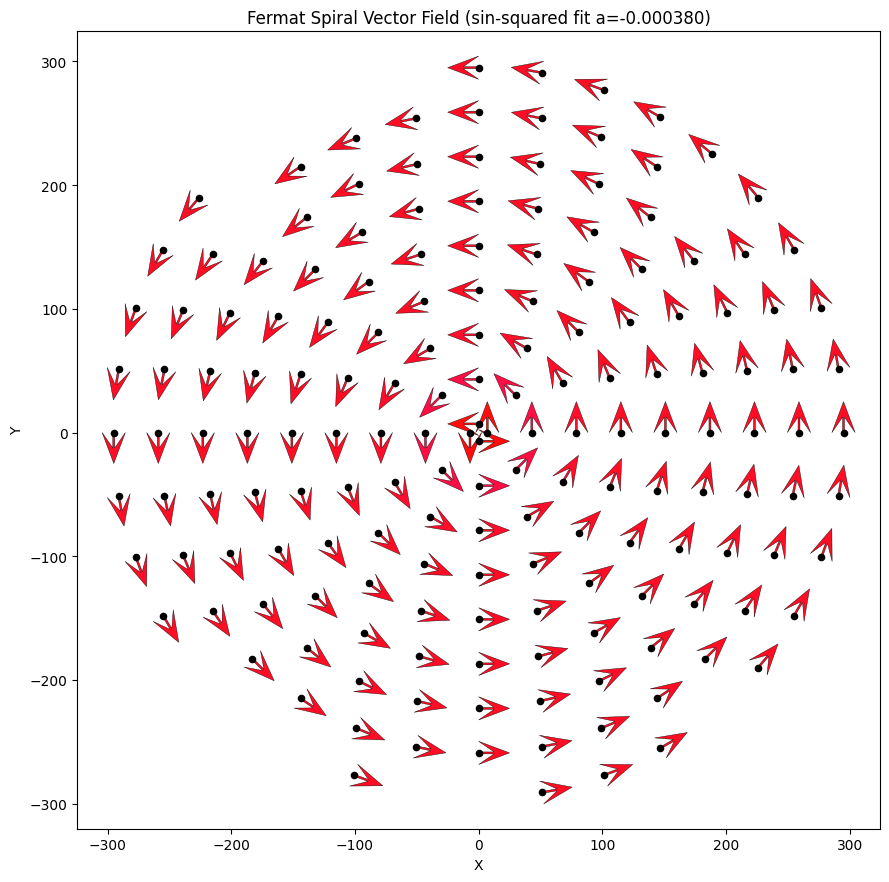

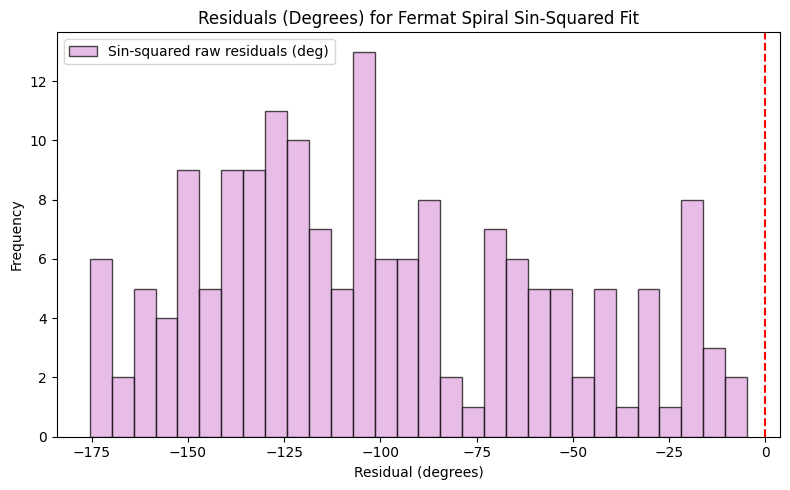

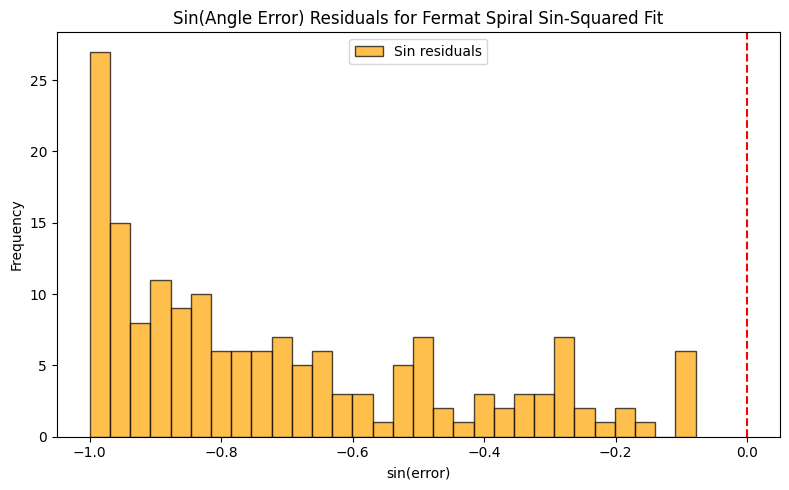

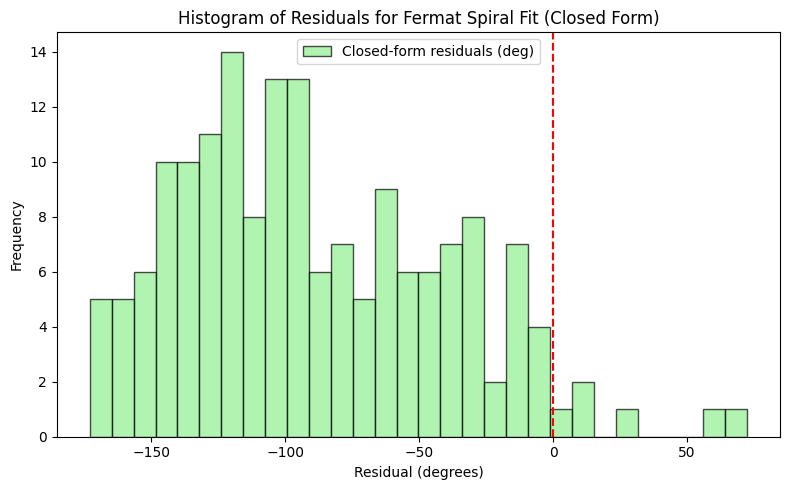

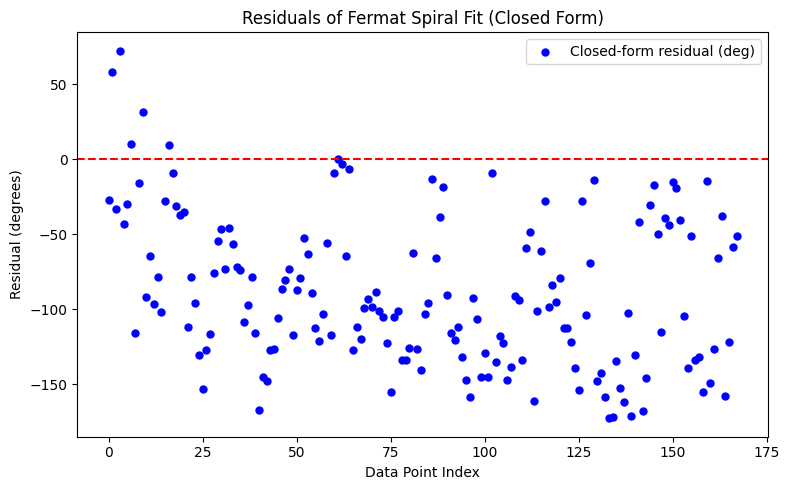

In [10]:
## Plot the vector field with the fitted Fermat spiral (sin-squared objective)
## Use a_opt2 from the sin-squared fit and keep original least-squares results intact.
eps = 1e-12
predicted_angles_fermat_sin = np.degrees(np.arctan(2 * r**2 / (a_opt2**2 + eps)))
# raw angular residuals (degrees) and sin-based residuals
residuals_fermat_sin_deg = angles_deg - predicted_angles_fermat_sin
residuals_fermat_sin = np.sin(np.deg2rad(residuals_fermat_sin_deg))

# Vector field construction for sin-squared fit (do not overwrite previously defined predicted_angles_fermat)
plt.figure(figsize=(9, 9))
U_fitted_scaled_sin = magnitude_scale * np.cos(np.deg2rad(predicted_angles_fermat_sin + np.degrees(theta)))
V_fitted_scaled_sin = magnitude_scale * np.sin(np.deg2rad(predicted_angles_fermat_sin + np.degrees(theta)))
q_fitted_sin = plt.quiver(
    X, Y, U_fitted_scaled_sin, V_fitted_scaled_sin, predicted_angles_fermat_sin,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Fermat Spiral Vector Field (sin-squared fit a={a_opt2:.6f})')
plt.tight_layout()
plt.show()

# Closed-form (least-squares) angles retained for comparison (a_opt1)
predicted_angles_closed = np.degrees(np.arctan(2 * r**2 / (a_opt1**2 + eps)))
residuals_closed = angles_deg - predicted_angles_closed

# Histograms of residuals
plt.figure(figsize=(8, 5))
plt.hist(residuals_fermat_sin_deg, bins=30, color='plum', edgecolor='black', alpha=0.7, label='Sin-squared raw residuals (deg)')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals (Degrees) for Fermat Spiral Sin-Squared Fit')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals_fermat_sin, bins=30, color='orange', edgecolor='black', alpha=0.7, label='Sin residuals')
plt.axvline(0, color='red', linestyle='--')
plt.title('Sin(Angle Error) Residuals for Fermat Spiral Sin-Squared Fit')
plt.xlabel('sin(error)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Closed-form residuals histogram (least-squares)
plt.figure(figsize=(8, 5))
plt.hist(residuals_closed, bins=30, color='lightgreen', edgecolor='black', alpha=0.7, label='Closed-form residuals (deg)')
plt.axvline(0, color='red', linestyle='--')
plt.title('Histogram of Residuals for Fermat Spiral Fit (Closed Form)')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Scatter of closed-form residuals
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals_closed)), residuals_closed, color='blue', s=25, label='Closed-form residual (deg)')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Fermat Spiral Fit (Closed Form)')
plt.legend()
plt.tight_layout()
plt.show()

## TODO

1. Write down the necessary theorems and proofs for the above problem at hand, and possibly use it as an example to motivate directional statistics
2. Change the residual information from a vector field to a line field. The reflective symmetry, as that of $\sin^2(x)$ should be reflected in the plots.
3. Use likelihoods / Bayes factors to compare between models.
4. Plot the spiral field lines on top of the image.


In [12]:
import numpy as np
from scipy.optimize import minimize

def minimize_spiral_parametric(params, angles_deg, r):
    """
    Fits the tangent angle (pitch) of a generalized spiral family.
    
    Model: tan(psi) = k * r^p
    This generalizes:
      p = 0: Logarithmic Spiral (constant pitch)
      p = 1: Archimedean Spiral (pitch grows linearly with r)
      p = -1: Hyperbolic Spiral
      
    Params:
      k: Winding steepness (collapsed A/b)
      p: Growth rate parameter
    """
    k, p = params
    
    # Calculate predicted tangent angle psi in radians
    # We do NOT use (r^p - 1)/p here because the derivative of the 
    # Box-Cox shape leads to purely r^p in the tangent definition.
    # tan(psi) = r * d(theta)/dr. If theta ~ (r^p-1)/p, then d(theta)/dr ~ r^(p-1).
    # Therefore, tan(psi) ~ r * r^(p-1) = r^p.
    
    # Robust power calculation to handle negative p or r=0
    # Add epsilon for numerical stability if p < 0
    term = k * (r + 1e-8)**p
    
    predicted_psi = np.arctan(term)
    predicted_angles_deg = np.degrees(predicted_psi)
    
    # CIRCULAR STATISTICS:
    # When minimizing angles, simple subtraction is dangerous due to wrapping.
    # e.g., 359 - 1 = 358 (huge error), but actually diff is 2.
    # We use a metric suitable for directional data: 1 - cos(diff)
    # or assuming these are tangent vectors within [-90, 90], simple diff might suffice.
    # I will use the vector-safe difference assuming angles are unwrapped or within range.
    
    residuals = angles_deg - predicted_angles_deg
    
    # Check for wrapping if angles cover a large range:
    # residuals = (residuals + 180) % 360 - 180
    
    return np.sum(residuals**2)

# --- Usage ---

# Example Dummy Data (Replace with your actual data)
# r = np.linspace(1, 10, 100)
# True parameters: k=0.5, p=1.0 (Archimedean)
# angles_deg = np.degrees(np.arctan(0.5 * r**1.0)) + np.random.normal(0, 1, 100)

# Initial guess: k=1.0, p=1.0 (Start with Archimedean assumption)
initial_params = [1.0, 1.0] 

# Bounds are helpful. p usually stays between -2 and 2 for natural spirals.
bounds = [(-np.inf, np.inf), (-5.0, 5.0)]

result_parametric = minimize(
    minimize_spiral_parametric, 
    initial_params, 
    args=(angles_deg, r),
    bounds=bounds
)

k_opt, p_opt = result_parametric.x

print(f"Optimization Results:")
print(f"k (steepness): {k_opt:.4f}")
print(f"p (family): {p_opt:.4f}")

# Interpretation
if abs(p_opt) < 0.1:
    print(">> Family approximates a Logarithmic Spiral.")
elif abs(p_opt - 1.0) < 0.1:
    print(">> Family approximates an Archimedean Spiral.")
elif abs(p_opt + 1.0) < 0.1:
    print(">> Family approximates a Hyperbolic Spiral.")
else:
    print(f">> Family is a generalized spiral of order {p_opt:.2f}.")

Optimization Results:
k (steepness): 733.4523
p (family): -3.9536
>> Family is a generalized spiral of order -3.95.


In [ ]:
import numpy as np
from scipy.optimize import minimize

def gprime(r, p):
    # derivative of g_p(r): ln(r) -> 1/r when p=0; else r^{p-1}
    return np.where(p == 0, 1.0 / r, r ** (p - 1))

def alpha_theta(r, A, b, p):
    gp = gprime(r, p)
    return np.arctan2(-b / r, A * gp)  # radians

def rho(r, A, b, p):
    gp = gprime(r, p)
    return np.sqrt(A**2 * gp**2 + (b**2) / (r**2))

def J_objective(params, angles_deg, r, p=0.0, sigma=1.0):
    """
    params: [A, b]
    angles_deg: observed angles (degrees)
    r: radii array
    p: spiral family parameter (0=log, 1=Archimedean, 2=Fermat, etc.)
    sigma: noise std (same units as angle residuals in radians)
    """
    A, b = params
    r_safe = np.aasrray(r, dtype=float) + 1e-12
    angles_rad = np.deg2rad(angles_deg)

    gp = gprime(r_safe, p)
    rho_i = rho(r_safe, A, b, p)

    # predicted direction in radians
    alpha_pred = alpha_theta(r_safe, A, b, p)

    # sin-based angular residuals
    ang_err = np.sin(angles_rad - alpha_pred)

    # negative log prior term
    log_term = np.log(A**2 * gp**2 + (b**2) / (r_safe**2))

    J = -np.sum(log_term) + (1.0 / (2.0 * sigma**2)) * np.sum((rho_i**2) * (ang_err**2))
    return J

# Example: fit log spiral (p=0) with sigma=1
p_family = 0.0          # set 1 for Archimedean, 2 for Fermat, etc.
sigma_hat = 1.0         # set your noise std; or estimate from residuals
initial = [1.0, 1.0]    # starting A, b

res = minimize(J_objective, initial, args=(angles_deg, r, p_family, sigma_hat), method="L-BFGS-B")
A_opt, b_opt = res.x
print(res)
print(f"A_opt={A_opt:.4f}, b_opt={b_opt:.4f}")

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 376.56993617496823
        x: [ 4.852e+01  7.435e+01]
      nit: 18
      jac: [-1.705e-05 -1.705e-05]
     nfev: 57
     njev: 19
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
A_opt=48.5179, b_opt=74.3492


| **Spiral Type** | **$g_p'(r)$** | **Vector Field** $F(r,\phi)$ | **Magnitude** $\rho(r)$ | **Weight** $w(r)=\rho(r)^2$ | **Weighted LS Objective** $L(\theta)$ |
|-----------------|---------------|-------------------------------|--------------------------|------------------------------|----------------------------------------|
| **Log Spiral** | $$\frac{1}{r}$$ | $$F_{\text{log}}(r,\phi)=\left(\frac{A}{r},\;-\frac{b}{r}\right)$$ | $$\rho_{\text{log}}(r)=\frac{\sqrt{A^2+b^2}}{r}$$ | $$w_{\text{log}}(r)=\frac{A^2+b^2}{r^2}$$ | $$L_{\text{log}}(\theta)=\sum_i \frac{A^2+b^2}{r_i^2}\ d^2(\hat{\alpha}_i,\alpha_\theta) = 1/b^2\sum_i \frac{1/k^2 + 1}{r_i^2}\ d^2(\hat{\alpha}_i,\alpha_\theta)  \\ = L_{\log}(k)$$ |
| **Archimedean Spiral** | $$1$$ | $$F_{\text{arch}}(r,\phi)=\left(A,\;-\frac{b}{r}\right)$$ | $$\rho_{\text{arch}}(r)=\sqrt{A^2+\frac{b^2}{r^2}}$$ | $$w_{\text{arch}}(r)=A^2+\frac{b^2}{r^2}$$ | $$L_{\text{arch}}(\theta)=\sum_i \left(A^2+\frac{b^2}{r_i^2}\right)\ d^2(\hat{\alpha}_i,\alpha_\theta)$$ |
| **Fermat Spiral** | $$r$$ | $$F_{\text{fermat}}(r,\phi)=\left(A r,\;-\frac{b}{r}\right)$$ | $$\rho_{\text{fermat}}(r)=\sqrt{A^2 r^2+\frac{b^2}{r^2}}$$ | $$w_{\text{fermat}}(r)=A^2 r^2+\frac{b^2}{r^2}$$ | $$L_{\text{fermat}}(\theta)=\sum_i \left(A^2 r_i^2+\frac{b^2}{r_i^2}\right)\ d^2(\hat{\alpha}_i,\alpha_\theta)$$ |
---
 
The statistical objective does not match with the weighted LS problem. 



## Maximizing log likelihood

## Model Selection

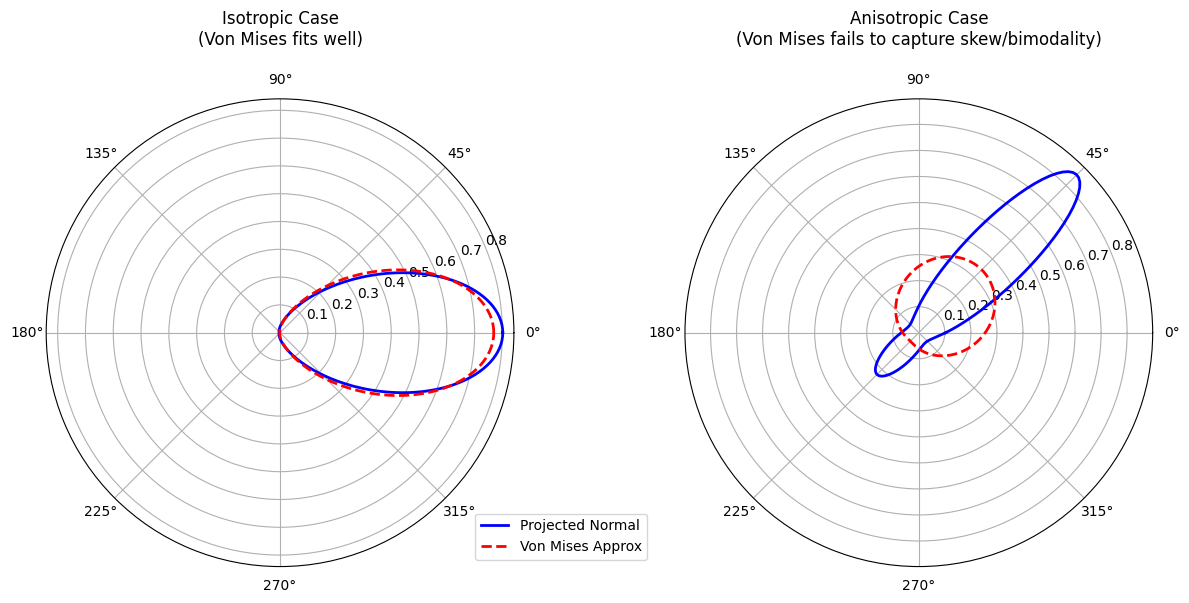

In [4]:
## Likelihood calculation using line field approach
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def line_field_pdf(psi, phi_0, m, sigma):
    """
    Calculates the probability density for the line field model.
    
    Args:
        psi (float or np.array): The data points (angles in radians).
        phi_0 (float): The orientation parameter to estimate.
        m (float): Magnitude/strength parameter.
        sigma (float): Standard deviation parameter.
        
    Returns:
        np.array: The probability density values.
    """
    # Calculate the angular difference
    delta = psi - phi_0
    
    # Pre-calculate common terms for efficiency
    cos_d = np.cos(delta)
    sin_d = np.sin(delta)
    m_sigma_ratio = m / sigma
    
    # Term 1: The isotropic baseline
    # Note: Using 1/pi as per your handwritten note
    term1 = (1.0 / np.pi) * np.exp(-0.5 * (m_sigma_ratio**2))
    
    # Term 2: The directional component
    # The exponential part: exp(-m^2 * sin^2 / 2sigma^2)
    exp_part = np.exp(-0.5 * (m_sigma_ratio * sin_d)**2)
    
    # The Phi part: 2 * Phi(...) - 1
    # Note: norm.cdf is the standard normal CDF (Phi)
    phi_arg = m_sigma_ratio * cos_d
    bracket_term = 2 * norm.cdf(phi_arg) - 1
    
    # Combine Term 2
    # coefficient: m * cos(delta) * (1 / (sqrt(2pi) * sigma))
    coeff = m * cos_d * (1.0 / (np.sqrt(2 * np.pi) * sigma))
    term2 = coeff * exp_part * bracket_term
    
    return term1 + term2

def neg_log_likelihood(params, psi_data, m, sigma):
    """
    The objective function to minimize.
    """
    phi_0 = params[0]
    
    # Calculate PDF values
    pdf_vals = line_field_pdf(psi_data, phi_0, m, sigma)
    
    # Safety check: Prevent log(0) or negative values due to float precision
    epsilon = 1e-15
    pdf_vals = np.maximum(pdf_vals, epsilon)
    
    # Return negative sum of logs
    return -np.sum(np.log(pdf_vals))

# --- Example Usage ---

# 1. Generate Dummy Data (Ground Truth: phi_0 = 1.0 radian)
np.random.seed(42)
true_phi = 1.0
m_val = 2.0
sigma_val = 0.5
# Create some noisy angular data clustered around true_phi and true_phi + pi
N = 77
# Simple von Mises distribution as a proxy generator for demonstration
data_psi = np.random.vonmises(true_phi, 4.0, N) 
# Randomly wrap some angles to simulate line field ambiguity (0 to pi)
data_psi = data_psi % np.pi 

# 2. Perform Optimization (Curve Fitting)
initial_guess = [0.0]  # Initial guess for phi_0

result = minimize(
    neg_log_likelihood, 
    initial_guess, 
    args=(data_psi, m_val, sigma_val),
    method='L-BFGS-B',  # Good for bound constraints if needed
    bounds=[(0, np.pi)] # Search within [0, pi]
)

# 3. Output Results
if result.success:
    estimated_phi = result.x[0]
    print(f"Optimization Successful!")
    print(f"True Phi_0 (approx): {true_phi}")
    print(f"Estimated Phi_0:     {estimated_phi:.4f}")
    print(f"Negative Log Likelihood: {result.fun:.4f}")
else:
    print("Optimization failed:", result.message)

Optimization Successful!
True Phi_0 (approx): 1.0
Estimated Phi_0:     0.9836
Negative Log Likelihood: 90.5293


Running 3D Grid Search...
True Params: A=2.0, b=1.0, p=1.05
Est. Params: A=3.50, b=2.00, p=1.26


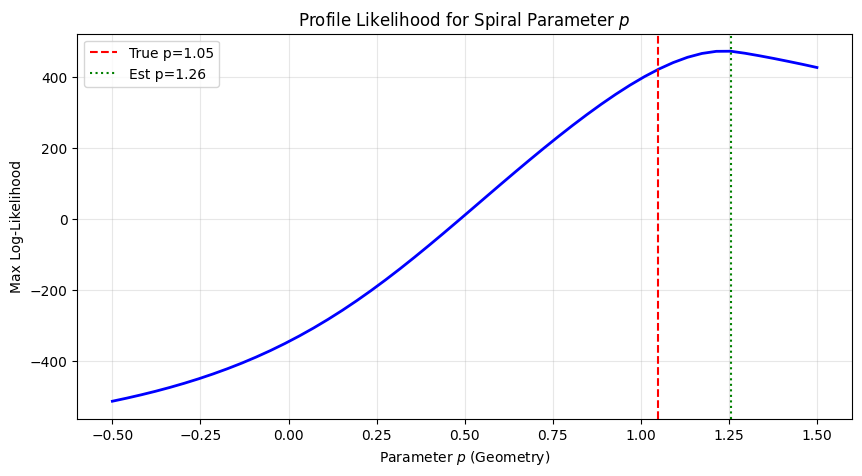

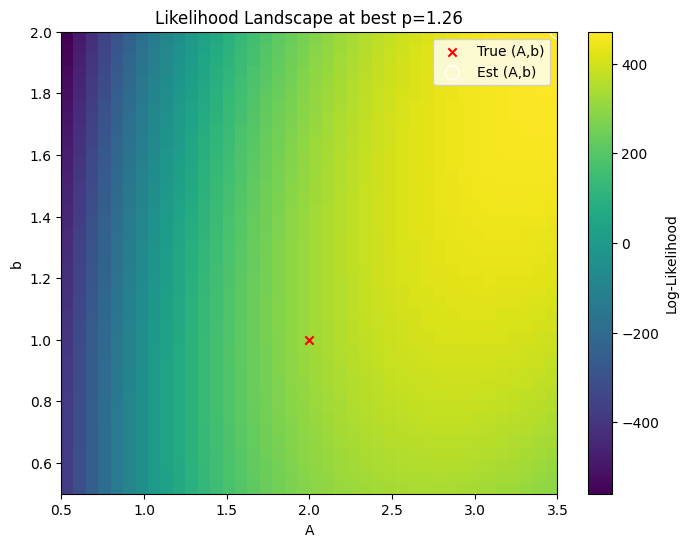

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def exact_projected_normal_pdf_3d(psi, phi0, m, sigma):
    """
    Computes PDF for 3D parameter grid inputs.
    """
    # Term 1: Background
    term1 = (1.0 / np.pi) * np.exp(-m**2 / (2 * sigma**2))
    
    diff = psi - phi0
    cos_d = np.cos(diff)
    sin_d = np.sin(diff)
    
    # Term 2: Directional
    coeff = (m * cos_d) / (np.sqrt(2 * np.pi) * sigma)
    exp_part = np.exp(-(m**2 * sin_d**2) / (2 * sigma**2))
    cdf_part = 2 * norm.cdf((m * cos_d) / sigma) - 1
    
    term2 = coeff * exp_part * cdf_part
    return np.maximum(term1 + term2, 1e-300)

def grid_search_3d(r_data, psi_data, param_ranges, sigma=1.0):
    """
    Performs MLE over (A, b, p).
    param_ranges: tuple (A_vals, b_vals, p_vals)
    """
    A_vals, b_vals, p_vals = param_ranges
    
    # 1. Create 4D Meshgrid
    # Dimensions: (Na, Nb, Np, N_data)
    # We use indexing='ij' so the dimensions order is A, b, p
    A_grid, b_grid, p_grid = np.meshgrid(A_vals, b_vals, p_vals, indexing='ij')
    
    # Expand to 4D for broadcasting against data
    A_4d = A_grid[..., np.newaxis]
    b_4d = b_grid[..., np.newaxis]
    p_4d = p_grid[..., np.newaxis]
    
    # Data shapes: (1, 1, 1, N_data)
    r_4d = r_data[np.newaxis, np.newaxis, np.newaxis, :]
    psi_4d = psi_data[np.newaxis, np.newaxis, np.newaxis, :]
    
    # 2. Vector Field Calculation (Universal Formula)
    # Fr = A * r^(p-1). This works for p=0 (1/r) and p!=0.
    Fr = A_4d * (r_4d ** (p_4d - 1.0))
    Fphi = -b_4d / r_4d
    
    # Magnitude and Phase
    m_4d = np.sqrt(Fr**2 + Fphi**2)
    phi0_4d = np.arctan(Fphi / (Fr + 1e-12))
    
    # 3. Compute PDF & Likelihood
    pdf_vals = exact_projected_normal_pdf_3d(psi_4d, phi0_4d, m_4d, sigma)
    
    # Sum logs over data dimension (axis 3)
    # Result shape: (Na, Nb, Np)
    log_likelihood_vol = np.sum(np.log(pdf_vals), axis=3)
    
    # 4. Find Global Maximum
    max_idx = np.unravel_index(np.argmax(log_likelihood_vol), log_likelihood_vol.shape)
    best_params = {
        'A': A_vals[max_idx[0]],
        'b': b_vals[max_idx[1]],
        'p': p_vals[max_idx[2]],
        'LL': log_likelihood_vol[max_idx]
    }
    
    return log_likelihood_vol, best_params

# --- Simulation and Test ---

# 1. Generate Data with a specific geometry (e.g., p=0.5)
np.random.seed(101)
true_p = 1.05   # Between Log and Archimedean
true_A = 2.0
true_b = 1.0
sigma_sim = 0.6
N = 600

r_obs = np.linspace(1, 10, N)
# True Vector Field
Fr_true = true_A * (r_obs**(true_p - 1))
Fphi_true = -true_b / r_obs
phi_true = np.arctan(Fphi_true / Fr_true)
psi_obs = phi_true + np.random.normal(0, 0.1, N) # Small noise
psi_obs = np.clip(psi_obs, -np.pi/2+0.01, np.pi/2-0.01)

# Load data
# psi_obs = phi mod \pi
# r_obs = r_obs

psi_obs = phi % np.pi

# 2. Define Search Ranges
# Note: 3D grids grow fast. Keep resolution manageable.
A_vals = np.linspace(0.5, 3.5, 40)
b_vals = np.linspace(0.5, 2.0, 40)
p_vals = np.linspace(-0.5, 1.5, 50) # Searching across different geometries

# 3. Run Search
print("Running 3D Grid Search...")
LL_vol, res = grid_search_3d(r_obs, psi_obs, (A_vals, b_vals, p_vals), sigma=sigma_sim)

print(f"True Params: A={true_A}, b={true_b}, p={true_p}")
print(f"Est. Params: A={res['A']:.2f}, b={res['b']:.2f}, p={res['p']:.2f}")

# --- Visualization: Profile Likelihood of p ---
# We take the max over A and b for each p.
# This answers: "For a fixed p, what is the best possible fit?"
profile_likelihood_p = np.max(LL_vol, axis=(0, 1))

plt.figure(figsize=(10, 5))
plt.plot(p_vals, profile_likelihood_p, 'b-', linewidth=2)
plt.axvline(true_p, color='r', linestyle='--', label=f'True p={true_p}')
plt.axvline(res['p'], color='g', linestyle=':', label=f'Est p={res["p"]:.2f}')

plt.title('Profile Likelihood for Spiral Parameter $p$')
plt.xlabel('Parameter $p$ (Geometry)')
plt.ylabel('Max Log-Likelihood')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Visualization 2: Slice at best p ---
# We plot the A-b landscape at the optimal p index
best_p_idx = np.where(p_vals == res['p'])[0][0]
LL_slice = LL_vol[:, :, best_p_idx]

plt.figure(figsize=(8, 6))
plt.imshow(
    LL_slice.T, 
    extent=[A_vals.min(), A_vals.max(), b_vals.min(), b_vals.max()],
    origin='lower', aspect='auto', cmap='viridis'
)
plt.colorbar(label='Log-Likelihood')
plt.scatter([true_A], [true_b], color='red', marker='x', label='True (A,b)')
plt.scatter([res['A']], [res['b']], facecolors='none', edgecolors='white', s=100, label='Est (A,b)')
plt.title(f'Likelihood Landscape at best p={res["p"]:.2f}')
plt.xlabel('A')
plt.ylabel('b')
plt.legend()
plt.show()